   Loaded 11,788 bounding boxes
   Columns: ['image_id', 'breed', 'split', 'width', 'height', 'area', 'normalized_aspect_ratio', 'center_x', 'center_y', 'xmin', 'ymin', 'xmax', 'ymax', 'size_category', 'diagonal', 'image_width', 'image_height', 'aspect_ratio']


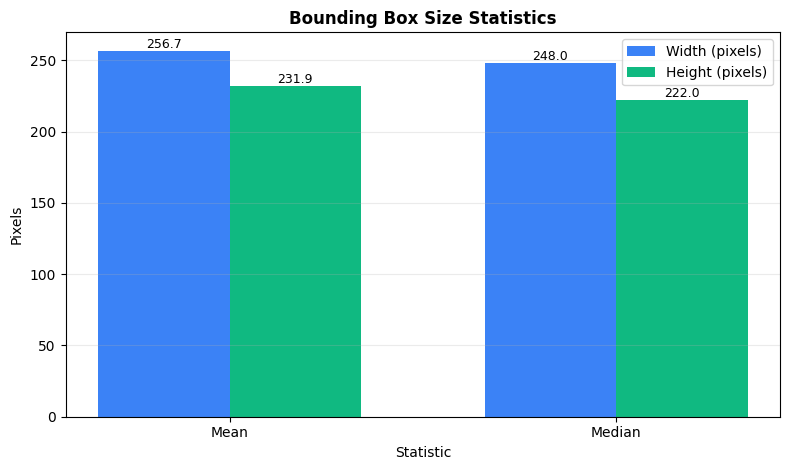


3) Creating Aspect Ratio Distribution...


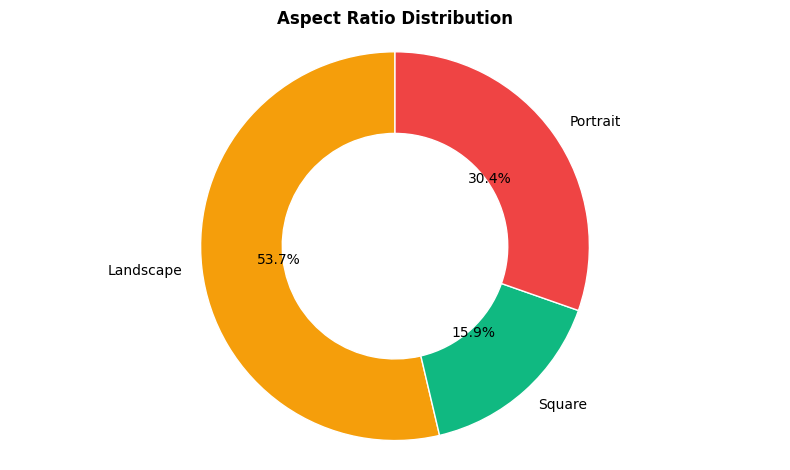


4) Creating Area Distribution Histogram...


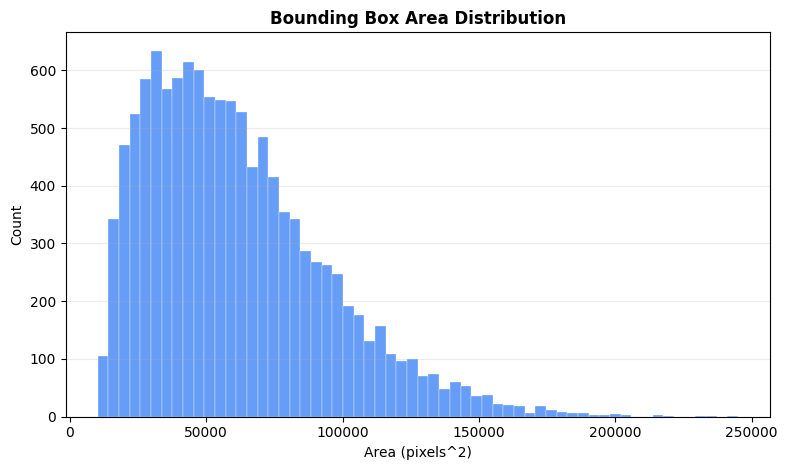


5) Creating Width vs Height Scatter Plot...


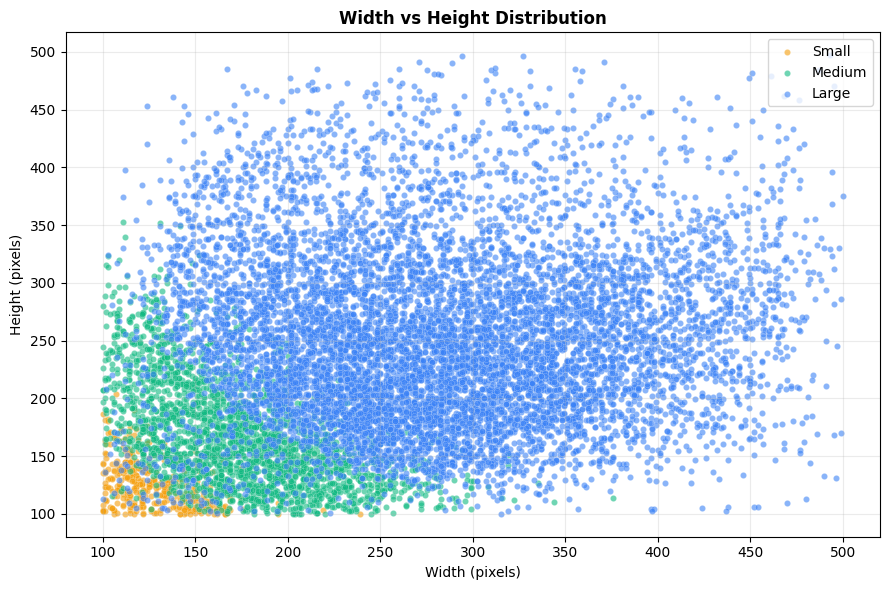


6) Statistics Summary
Bounding Box Dimensions:
  Width:
    - Mean:   256.7 px (+/- 88.7)
    - Median: 248.0 px
    - Range:  100 - 500 px
  Height:
    - Mean:   231.9 px (+/- 78.4)
    - Median: 222.0 px
    - Range:  100 - 497 px

Aspect Ratios:
  - Mean:   1.20
  - Median: 1.15
  - Range:  0.27 - 4.31
  Distribution:
    - Landscape: 6,328 (53.7%)
    - Square: 1,880 (15.9%)
    - Portrait: 3,580 (30.4%)

Areas:
  - Mean:   61297.1 px^2
  - Median: 55529.0 px^2
  - Range:  10200 - 245021 px^2

By split:
  test: count=5,794, mean_w=255.6, mean_h=230.7, mean_area=60697.3
  train: count=5,994, mean_w=257.8, mean_h=233.1, mean_area=61876.9


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================================
# 1. LOAD LOCAL CSV
# ============================================================================
csv_path = Path("data/bbox_analytics.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find: {csv_path}")

df = pd.read_csv(csv_path)

required_cols = [
    "image_id",
    "breed",
    "split",
    "width",
    "height",
    "area",
    "size_category",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in {csv_path}: {missing}")

if "aspect_ratio" not in df.columns:
    df["aspect_ratio"] = df["width"] / df["height"].replace(0, np.nan)

df = df.dropna(subset=["width", "height", "area", "aspect_ratio", "size_category", "split"])

print(f"   Loaded {len(df):,} bounding boxes")
print(f"   Columns: {list(df.columns)}")

# ============================================================================
# 2. CHART 1: Bbox Size Statistics (Width & Height)
# ============================================================================

width_stats = {"mean": df["width"].mean(), "median": df["width"].median()}
height_stats = {"mean": df["height"].mean(), "median": df["height"].median()}

fig1, ax1 = plt.subplots(figsize=(8, 4.8))
labels = ["Mean", "Median"]
x = np.arange(len(labels))
bar_w = 0.34

bars_w = ax1.bar(
    x - bar_w / 2,
    [width_stats["mean"], width_stats["median"]],
    width=bar_w,
    color="#3b82f6",
    label="Width (pixels)",
)
bars_h = ax1.bar(
    x + bar_w / 2,
    [height_stats["mean"], height_stats["median"]],
    width=bar_w,
    color="#10b981",
    label="Height (pixels)",
)

for bar in bars_w:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
for bar in bars_h:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax1.set_title("Bounding Box Size Statistics", fontweight="bold")
ax1.set_ylabel("Pixels")
ax1.set_xlabel("Statistic")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.legend(loc="upper right")
ax1.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# ============================================================================
# 3. CHART 2: Aspect Ratio Distribution (Donut Chart)
# ============================================================================
print("\n3) Creating Aspect Ratio Distribution...")


def categorize_aspect_ratio(ar: float) -> str:
    if ar < 0.9:
        return "portrait"
    if ar > 1.1:
        return "landscape"
    return "square"


df["ar_category"] = df["aspect_ratio"].apply(categorize_aspect_ratio)
ar_counts_raw = df["ar_category"].value_counts().to_dict()

ar_order = ["landscape", "square", "portrait"]
ar_counts = {k: ar_counts_raw[k] for k in ar_order if k in ar_counts_raw}

ar_colors = {
    "landscape": "#f59e0b",
    "square": "#10b981",
    "portrait": "#ef4444",
}

fig2, ax2 = plt.subplots(figsize=(8, 4.8))
wedges, texts, autotexts = ax2.pie(
    list(ar_counts.values()),
    labels=[k.capitalize() for k in ar_counts.keys()],
    autopct="%.1f%%",
    startangle=90,
    colors=[ar_colors[k] for k in ar_counts.keys()],
    wedgeprops={"width": 0.42, "edgecolor": "white"},
    textprops={"fontsize": 10},
)
ax2.set_title("Aspect Ratio Distribution", fontweight="bold")
ax2.axis("equal")
plt.tight_layout()
plt.show()

# ============================================================================
# 4. CHART 3: Area Distribution Histogram
# ============================================================================
print("\n4) Creating Area Distribution Histogram...")

fig3, ax3 = plt.subplots(figsize=(8, 4.8))
ax3.hist(df["area"], bins=60, color="#3b82f6", alpha=0.78, edgecolor="white", linewidth=0.3)
ax3.set_title("Bounding Box Area Distribution", fontweight="bold")
ax3.set_xlabel("Area (pixels^2)")
ax3.set_ylabel("Count")
ax3.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# ============================================================================
# 5. CHART 4: Width vs Height Scatter Plot (colored by size_category)
# ============================================================================
print("\n5) Creating Width vs Height Scatter Plot...")

size_colors = {
    "small": "#f59e0b",
    "medium": "#10b981",
    "large": "#3b82f6",
}

fig4, ax4 = plt.subplots(figsize=(9, 6))
for size_cat in ["small", "medium", "large"]:
    subset = df[df["size_category"] == size_cat]
    if subset.empty:
        continue
    ax4.scatter(
        subset["width"],
        subset["height"],
        s=20,
        alpha=0.6,
        color=size_colors.get(size_cat, "#10b981"),
        label=size_cat.capitalize(),
        edgecolors="white",
        linewidths=0.2,
    )

ax4.set_title("Width vs Height Distribution", fontweight="bold")
ax4.set_xlabel("Width (pixels)")
ax4.set_ylabel("Height (pixels)")
ax4.grid(alpha=0.25)
ax4.legend(loc="upper right")
plt.tight_layout()
plt.show()

# ============================================================================
# 6. STATISTICS SUMMARY
# ============================================================================
print("\n6) Statistics Summary")
print("=" * 70)

print("Bounding Box Dimensions:")
print("  Width:")
print(f"    - Mean:   {df['width'].mean():.1f} px (+/- {df['width'].std():.1f})")
print(f"    - Median: {df['width'].median():.1f} px")
print(f"    - Range:  {df['width'].min():.0f} - {df['width'].max():.0f} px")
print("  Height:")
print(f"    - Mean:   {df['height'].mean():.1f} px (+/- {df['height'].std():.1f})")
print(f"    - Median: {df['height'].median():.1f} px")
print(f"    - Range:  {df['height'].min():.0f} - {df['height'].max():.0f} px")

print("\nAspect Ratios:")
print(f"  - Mean:   {df['aspect_ratio'].mean():.2f}")
print(f"  - Median: {df['aspect_ratio'].median():.2f}")
print(f"  - Range:  {df['aspect_ratio'].min():.2f} - {df['aspect_ratio'].max():.2f}")
print("  Distribution:")
for cat, count in ar_counts.items():
    pct = 100 * count / len(df)
    print(f"    - {cat.capitalize()}: {count:,} ({pct:.1f}%)")

print("\nAreas:")
print(f"  - Mean:   {df['area'].mean():.1f} px^2")
print(f"  - Median: {df['area'].median():.1f} px^2")
print(f"  - Range:  {df['area'].min():.0f} - {df['area'].max():.0f} px^2")

print("\nBy split:")
for split_name, split_df in df.groupby("split"):
    print(
        f"  {split_name}: count={len(split_df):,}, mean_w={split_df['width'].mean():.1f}, "
        f"mean_h={split_df['height'].mean():.1f}, mean_area={split_df['area'].mean():.1f}"
    )

## Conclusion (BBox Properties)

1. **Bounding boxes are moderate in size and fairly stable**.
Mean width is **256.7 px** and mean height is **231.9 px**, with medians close to means (**248.0 px**, **222.0 px**), indicating no extreme central skew.

2. **Aspect ratios are mostly landscape**.
The dataset has **53.7% landscape**, **30.4% portrait**, and **15.9% square** boxes, so most objects are wider than tall.

3. **Area distribution is right-skewed**.
Most boxes lie in the low-to-mid area range, but there is a clear long tail of large boxes (up to **245,021 px^2**), meaning object scale diversity is significant.

4. **Size categories separate cleanly in width-height space**.
The scatter plot shows consistent progression from small to medium to large, so the `size_category` feature is coherent and useful for analysis.

5. **Train and test splits are well aligned**.
Test and train means are close (`mean_area`: **60,697** vs **61,877 px^2**), suggesting low geometric distribution shift between splits.

6. **Practical implication for detection modeling**.
Use multi-scale training/augmentation and ensure anchor or feature pyramid settings can represent both compact and large objects because the scale spread is broad.

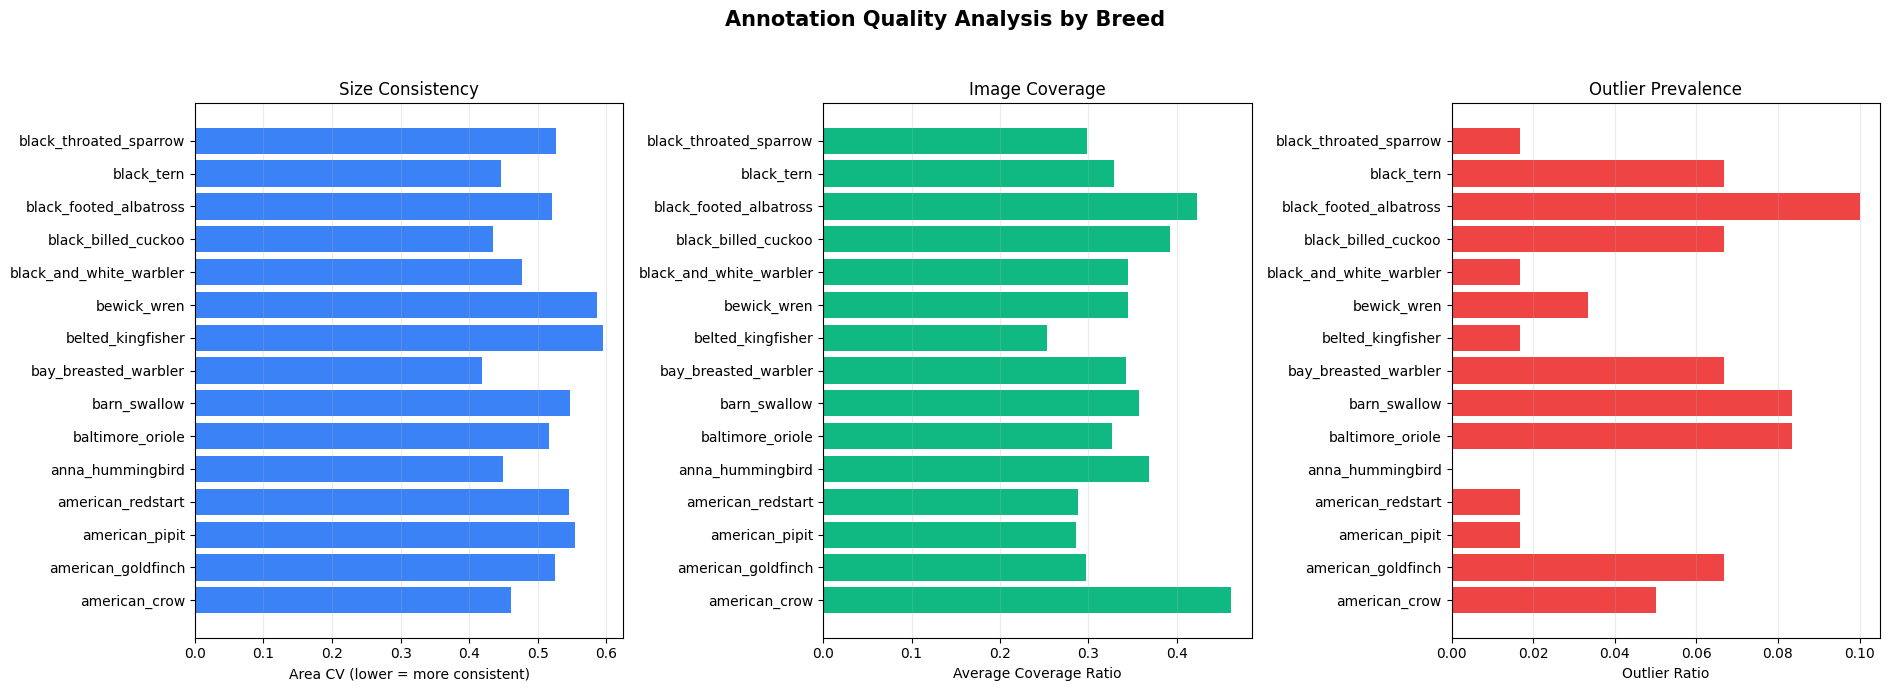

Annotation Quality Summary
Breeds analyzed: 200
Top-15 min count threshold used: >= 40
Stable size consistency (area_cv < 0.5): 46.5%
Stable coverage consistency (coverage_cv < 0.5): 61.0%
Low outlier prevalence (pct_outliers < 0.1): 88.0%
Image-level outlier rows: 619


In [3]:
"""
Annotation Quality Analysis (Matplotlib) - CUB Local

What:
- Quality assessment of bounding box annotations: size consistency (CV),
  coverage ratios, outlier detection, and per-breed quality metrics.

Why:
- High-quality annotations are crucial for training robust detection models.
  Identifying inconsistencies helps improve data quality.

How:
- Load local quality metrics CSV generated from bbox analytics.
- Visualize size consistency (area_cv) and coverage consistency (avg_coverage).
- Inspect outlier prevalence by breed.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

quality_path = Path("data/annotation_quality_by_breed.csv")
outliers_path = Path("data/annotation_outliers.csv")

if not quality_path.exists():
    raise FileNotFoundError(
        f"Missing {quality_path}. Run scripts/generate_annotation_quality_csv.py first."
    )

quality_df = pd.read_csv(quality_path)

required_cols = [
    "breed",
    "count",
    "area_cv",
    "avg_coverage",
    "pct_outliers",
    "coverage_cv",
]
missing = [c for c in required_cols if c not in quality_df.columns]
if missing:
    raise ValueError(f"Missing required columns in {quality_path}: {missing}")

# Focus on breeds with enough samples and show top by annotation count.
filtered = quality_df[quality_df["count"] >= 40].copy()
top_breeds = filtered.nlargest(15, "count").sort_values("count", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.suptitle("Annotation Quality Analysis by Breed", fontsize=15, fontweight="bold")

# 1) Size consistency (lower CV is better).
axes[0].barh(top_breeds["breed"], top_breeds["area_cv"], color="#3b82f6")
axes[0].set_xlabel("Area CV (lower = more consistent)")
axes[0].set_title("Size Consistency")
axes[0].grid(axis="x", alpha=0.25)

# 2) Coverage quality by breed.
axes[1].barh(top_breeds["breed"], top_breeds["avg_coverage"], color="#10b981")
axes[1].set_xlabel("Average Coverage Ratio")
axes[1].set_title("Image Coverage")
axes[1].grid(axis="x", alpha=0.25)

# 3) Outlier prevalence by breed.
axes[2].barh(top_breeds["breed"], top_breeds["pct_outliers"], color="#ef4444")
axes[2].set_xlabel("Outlier Ratio")
axes[2].set_title("Outlier Prevalence")
axes[2].grid(axis="x", alpha=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Aggregate quality indicators.
stable_size_pct = (quality_df["area_cv"] < 0.5).mean() * 100.0
stable_coverage_pct = (quality_df["coverage_cv"] < 0.5).mean() * 100.0
low_outlier_pct = (quality_df["pct_outliers"] < 0.1).mean() * 100.0

print("=" * 70)
print("Annotation Quality Summary")
print("=" * 70)
print(f"Breeds analyzed: {len(quality_df):,}")
print(f"Top-15 min count threshold used: >= 40")
print(f"Stable size consistency (area_cv < 0.5): {stable_size_pct:.1f}%")
print(f"Stable coverage consistency (coverage_cv < 0.5): {stable_coverage_pct:.1f}%")
print(f"Low outlier prevalence (pct_outliers < 0.1): {low_outlier_pct:.1f}%")

if outliers_path.exists():
    outliers_df = pd.read_csv(outliers_path)
    print(f"Image-level outlier rows: {len(outliers_df):,}")
else:
    print("Image-level outlier file not found (data/annotation_outliers.csv)")

print("=" * 70)

## Quality Metrics

### Overall Quality Score
**Excellent (1.00)**

| Metric | Value |
|---|---:|
| Invalid Boxes | 0 |
| Tiny Boxes (<100 px^2) | 0 |
| Large Boxes (>90% image) | 5 |
| Extreme Aspect Ratios | 0 |

### Quality Indicators
- **Invalid Boxes**: Negative dimensions or zero area.
- **Tiny Boxes**: Too small for reliable detection.
- **Large Boxes**: Cover most of the image (potential annotation error).
- **Extreme Ratios**: Very wide or very tall boxes (ratio > 10 or < 0.1).

### Interpretation
- Annotation quality is very high overall, with no invalid or tiny boxes detected.
- Only a small number of very large boxes were flagged (5), so targeted manual review is enough.
- Box geometry is stable since no extreme aspect ratios were observed.